# Ariadne: results

What Ariadne's serving stack measured on Lambda GPUs between 2026-09-27 and 2026-10-07, answering the
brief's questions. Every number comes from a committed file in `metrics/` (loaded by `report/results.py`), so
`make report` rebuilds this notebook and its charts from the repo. Each section cites the findings it rests on
(`design/findings.md`, F-numbers) and the decisions behind it (`design/decisions.md`, D-numbers).

**The setup.** The doctor is an agent that diagnoses Kubernetes faults in 5 to 16 chained model calls per run. It runs
on self-hosted vLLM behind a Go gateway that guards, admits, places and queues every call (D-42). The golden set is 26
recorded faults in four tiers, scored twice (v1, and the stricter v2, D-41).

In [1]:
import re
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from report.results import FIGURES, by_label, histogram, kv_measured, prom, rows, summary, total
from serving import fit, profiles

ROOT = Path.cwd()                           # the kernel runs in the repo root (report/build.py)

# The reference palette's first three categorical slots (they validate for every pair), light surface and ink.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "legend.frameon": False,
})
FIGURES.mkdir(parents=True, exist_ok=True)

def show(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=160)
    plt.close(fig)
    display(Image(filename=str(FIGURES / f"{name}.png")))

def table(header, body):
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    lines += ["| " + " | ".join(str(c) for c in r) + " |" for r in body]
    display(Markdown("\n".join(lines)))

def pct(x):
    return f"{x:.1%}"

def ci(s):
    return f"[{s['pass_rate_v2_ci95'][0]:.0%}–{s['pass_rate_v2_ci95'][1]:.0%}]"

## 1. What the app sends: shared tokens against unique ones

Every call starts with the same ~3.8k-token prefix: the triage ruleset, the tool schemas and the cluster card. Each step
then appends the previous answer and a new tool result, so step *n*'s prompt is step *n−1*'s plus a little more. vLLM
computes only that new tail, as long as the step runs on the worker that served the last one. The gateway's stickiness
keeps it there (F8–F11).

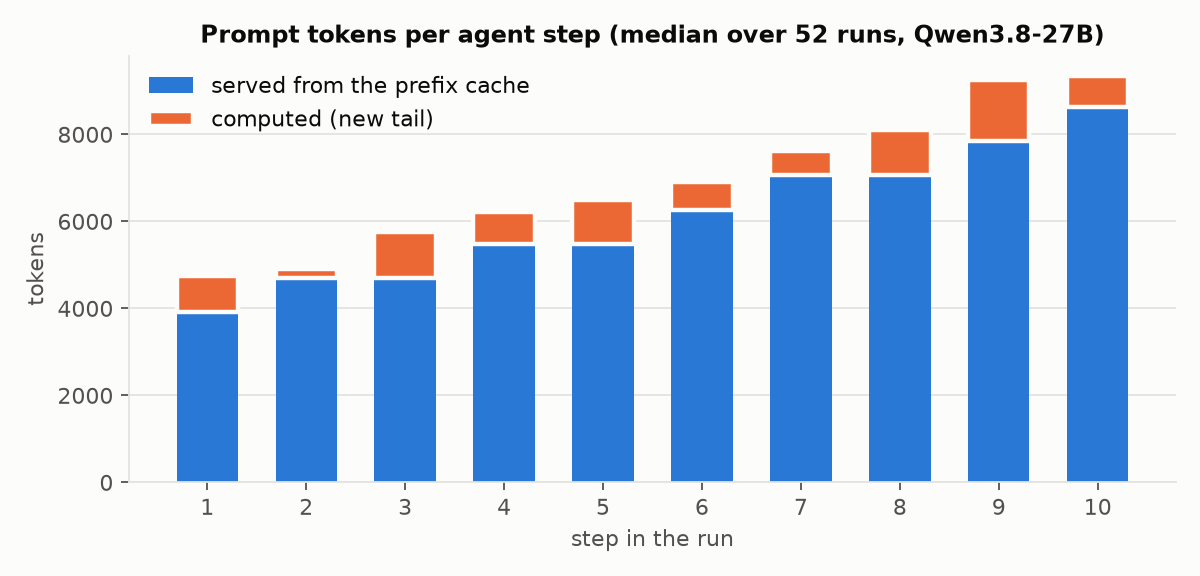

Over every step of the run, **87.8%** of prompt tokens came from the cache.

In [2]:
r = rows("gw-38-20261006-131640")
steps = range(1, 11)
def median(xs):
    xs = sorted(xs)
    return xs[len(xs) // 2] if xs else 0
cached = [median([x["cached_tokens"][i - 1] or 0 for x in r if len(x["cached_tokens"]) >= i]) for i in steps]
prompt = [median([x["prompt_tokens"][i - 1] or 0 for x in r if len(x["prompt_tokens"]) >= i]) for i in steps]
uncached = [p - c for p, c in zip(prompt, cached, strict=True)]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(steps, cached, color=BLUE, width=0.62, label="served from the prefix cache")
ax.bar(steps, uncached, bottom=cached, color=ORANGE, width=0.62, label="computed (new tail)",
       edgecolor=SURFACE, linewidth=2)
ax.set(title="Prompt tokens per agent step (median over 52 runs, Qwen3.8-27B)", xlabel="step in the run",
       ylabel="tokens", xticks=list(steps))
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")
show(fig, "prompt_per_step")
s = summary("gw-38-20261006-131640")
display(Markdown(f"Over every step of the run, **{pct(s['cached_share_of_prompt'])}** of prompt tokens came from the cache."))

## 2. Which model: quality on the golden set

The same 26 tasks, twice each, scored v2 with 95% Wilson intervals. Qwen3.8-27B (FP8, Aug 2026)'s interval sits above the
8B's, and it is probably better than the 30B-A3B, whose interval overlaps it slightly (F1). The 8B scores the same
through the gateway as direct, so routing changes where a call runs and not what it answers (F2).

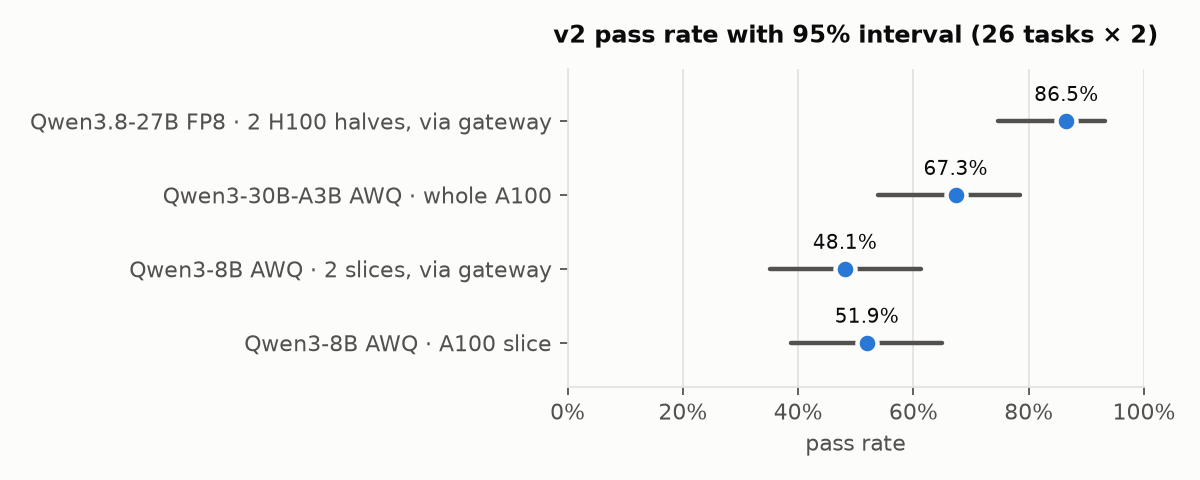

| Model, where | v2 pass [95% CI] | easy | multi-hop | red herring | rightsizing |
|---|---|---|---|---|---|
| Qwen3-8B AWQ · A100 slice | 51.9% [39%–65%] | 67.9% | 42.9% | 25.0% | 0.0% |
| Qwen3-8B AWQ · 2 slices, via gateway | 48.1% [35%–61%] | 60.7% | 42.9% | 25.0% | 0.0% |
| Qwen3-30B-A3B AWQ · whole A100 | 67.3% [54%–78%] | 75.0% | 50.0% | 75.0% | 50.0% |
| Qwen3.8-27B FP8 · 2 H100 halves, via gateway | 86.5% [75%–93%] | 89.3% | 71.4% | 100.0% | 100.0% |

In [3]:
models = [
    ("Qwen3-8B AWQ · A100 slice", "baseline-20260928-161531"),
    ("Qwen3-8B AWQ · 2 slices, via gateway", "gw-ptl-20261004-162326"),
    ("Qwen3-30B-A3B AWQ · whole A100", "30b-smoke-20260928-164635"),
    ("Qwen3.8-27B FP8 · 2 H100 halves, via gateway", "gw-38-20261006-131640"),
]
fig, ax = plt.subplots(figsize=(7.5, 3.0))
for y, (_, run) in enumerate(models):
    s = summary(run)
    lo, hi = s["pass_rate_v2_ci95"]
    ax.plot([lo, hi], [y, y], color=INK2, linewidth=2, solid_capstyle="round")
    ax.plot(s["pass_rate_v2"], y, "o", color=BLUE, markersize=9, markeredgecolor=SURFACE, markeredgewidth=2)
    ax.annotate(pct(s["pass_rate_v2"]), (s["pass_rate_v2"], y), xytext=(0, 9), textcoords="offset points",
                ha="center", color=INK, fontsize=9)
ax.set_yticks(range(len(models)), [m[0] for m in models])
ax.set(xlim=(0, 1), ylim=(-0.6, len(models) - 0.3), xlabel="pass rate")
ax.set_title("v2 pass rate with 95% interval (26 tasks × 2)", pad=12)
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
ax.grid(axis="y", visible=False)
show(fig, "model_quality")
table(["Model, where", "v2 pass [95% CI]", "easy", "multi-hop", "red herring", "rightsizing"],
      [[name, f"{pct(summary(run)['pass_rate_v2'])} {ci(summary(run))}"]
       + [pct(summary(run)["pass_rate_by_tier_v2"].get(t, 0)) for t in ("easy", "multi_hop", "red_herring", "rightsizing")]
       for name, run in models])

## 3. Capacity on paper against what vLLM measured

`serving/fit.py` predicts each worker's KV pool from the model's config and the slice's memory. vLLM reports the real
pool at startup (`make kv`). The fit is within 1–6% for standard-attention models, and 20–34% optimistic for the hybrid
Qwen3.8, more so on a smaller slice (F5). On an H100 half that leaves room for about two full-length (24k-token) runs
per worker, which makes KV the first limiter (F6).

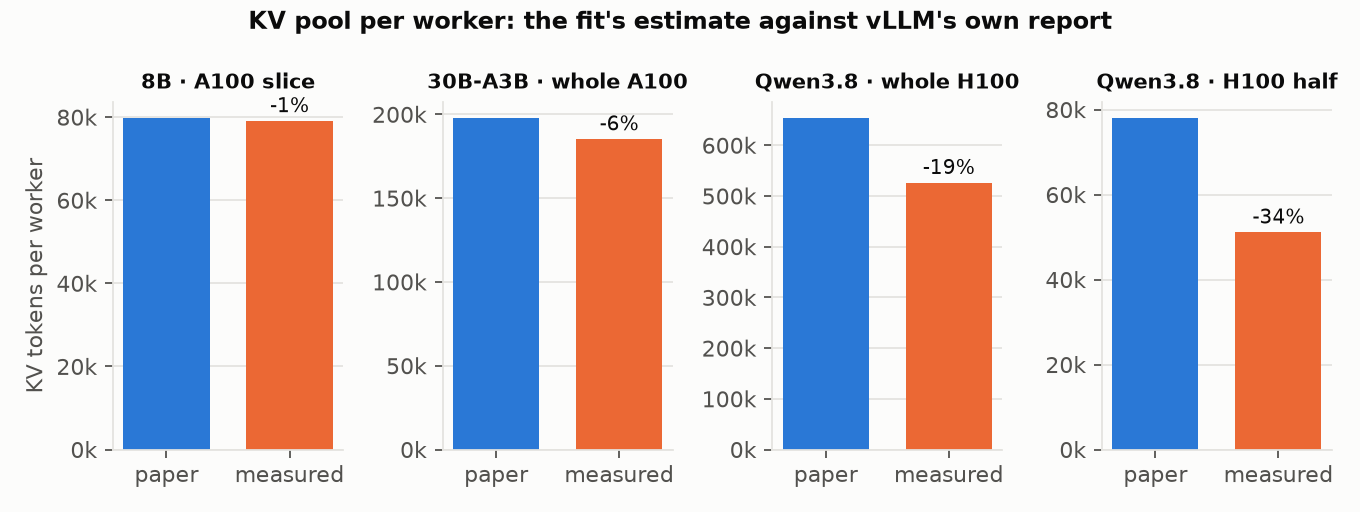

| Pair | paper | measured | gap |
|---|---|---|---|
| 8B · A100 slice | 79,699 | 79,056 | -0.8% |
| 30B-A3B · whole A100 | 197,563 | 185,136 | -6.3% |
| Qwen3.8 · whole H100 | 653,004 | 525,797 | -19.5% |
| Qwen3.8 · H100 half | 77,926 | 51,092 | -34.4% |

In [4]:
pairs = [("qwen3-8b-awq", "sliced", "8B · A100 slice"), ("qwen3-30b-a3b-2507-awq", "full", "30B-A3B · whole A100"),
         ("qwen3.8-27b-fp8", "h100-full", "Qwen3.8 · whole H100"), ("qwen3.8-27b-fp8", "h100-half", "Qwen3.8 · H100 half")]
paper, measured = [], []
for model, topo, _ in pairs:
    paper.append(fit.fit(profiles.load_profile(model), topo)["tokens_paper"])
    measured.append(kv_measured(model, topo))
fig, axes = plt.subplots(1, len(pairs), figsize=(8.5, 3.2))
for ax, (_, _, label), p, m in zip(axes, pairs, paper, measured, strict=True):
    ax.bar([0], [p], color=BLUE, width=0.7)
    ax.bar([1], [m], color=ORANGE, width=0.7)
    ax.set_xticks([0, 1], ["paper", "measured"])
    ax.set_title(label, fontsize=9.5)
    ax.annotate(f"{m / p - 1:+.0%}", (1, m), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)
    ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("KV tokens per worker")
fig.suptitle("KV pool per worker: the fit's estimate against vLLM's own report", fontweight="bold", fontsize=11)
show(fig, "kv_fit")
table(["Pair", "paper", "measured", "gap"],
      [[label, f"{p:,}", f"{m:,}", f"{m / p - 1:+.1%}"] for (_, _, label), p, m in zip(pairs, paper, measured, strict=True)])

## 4. Placement: does keeping a run on its worker matter?

The same golden workload twice on two Qwen3.8 halves at concurrency 4, changing only the gateway's pick policy:
`prefix_then_load` keeps a run on the worker that holds its history, and `least_loaded` ignores history. Answers are
the same. Without stickiness, vLLM recomputed 10% more prompt tokens and steps were 8–11% slower (F29). The gap is modest at this
load because the two workers are evenly loaded, so `least_loaded` often picks the run's previous worker anyway.

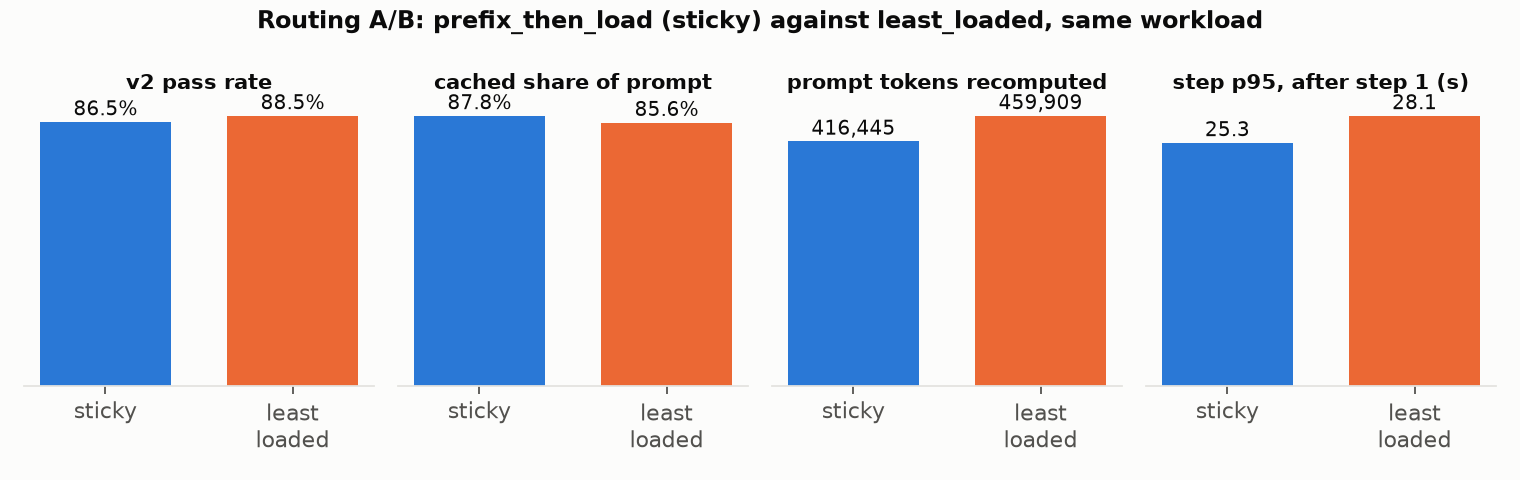

Under `least_loaded`, **77%** of continuing steps happened to land on the worker holding their history; under `prefix_then_load` it was 94% even across the overloaded sweep (F29).

In [5]:
arms = [("prefix_then_load", "gw-38-20261006-131640"), ("least_loaded", "gw-38-ll-20261006-140918")]
def uncached(run):
    return sum(sum(p or 0 for p in x["prompt_tokens"]) - sum(c or 0 for c in x["cached_tokens"]) for x in rows(run))
def p95_after_first(run):
    xs = sorted(t for x in rows(run) for t in x["latency_s"][1:] if t)
    return xs[int(0.95 * len(xs))]
metrics_ab = [("v2 pass rate", lambda r: summary(r)["pass_rate_v2"], "{:.1%}"),
              ("cached share of prompt", lambda r: summary(r)["cached_share_of_prompt"], "{:.1%}"),
              ("prompt tokens recomputed", uncached, "{:,.0f}"),
              ("step p95, after step 1 (s)", p95_after_first, "{:.1f}")]
fig, axes = plt.subplots(1, len(metrics_ab), figsize=(9.5, 3.0))
for ax, (title, f, fmt) in zip(axes, metrics_ab, strict=True):
    vals = [f(run) for _, run in arms]
    ax.bar([0, 1], vals, color=[BLUE, ORANGE], width=0.7)
    for i, v in enumerate(vals):
        ax.annotate(fmt.format(v), (i, v), xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
    ax.set_xticks([0, 1], ["sticky", "least\nloaded"])
    ax.set_title(title, fontsize=9.5)
    ax.set_yticks([])
    ax.grid(False)
    ax.spines["left"].set_visible(False)
fig.suptitle("Routing A/B: prefix_then_load (sticky) against least_loaded, same workload", fontweight="bold", fontsize=11)
show(fig, "routing_ab")
g = by_label(prom("gateway-gw-38-ll-20261006-142337"), "orch_sticky_total", "outcome")
cont = g.get("hit", 0) + g.get("broken_load", 0) + g.get("broken_shed", 0)
display(Markdown(f"Under `least_loaded`, **{g.get('hit', 0) / cont:.0%}** of continuing steps happened to land on the "
                 "worker holding their history; under `prefix_then_load` it was 94% even across the overloaded sweep (F29)."))

## 5. Under load: the knee, and sizing admission to KV

This section runs the golden set at rising concurrency on two Qwen3.8 halves, 26 tasks per level. On 10-06 the gateway
allowed 16 requests in flight per worker, and runs failed past 8 concurrent. Each refused step ended its run, and at 32
vLLM preempted (F24, F25). On 10-07 we tested two changes on one faster node (an H100 SXM5). The doctor now waits out a
refusal (D-44), and the gateway sizes the in-flight cap to the measured KV pool, 4 per half (D-43). The cap cut vLLM
preemptions by ~95%, kept more of the cache and lowered tail latency. But fewer runs finished, because queued requests
hit the gateway's deadline before the retries ran out (F36). Sizing for zero preemption is stricter than the workload
needs, so the next step is a cap of 6–8 (backlog).

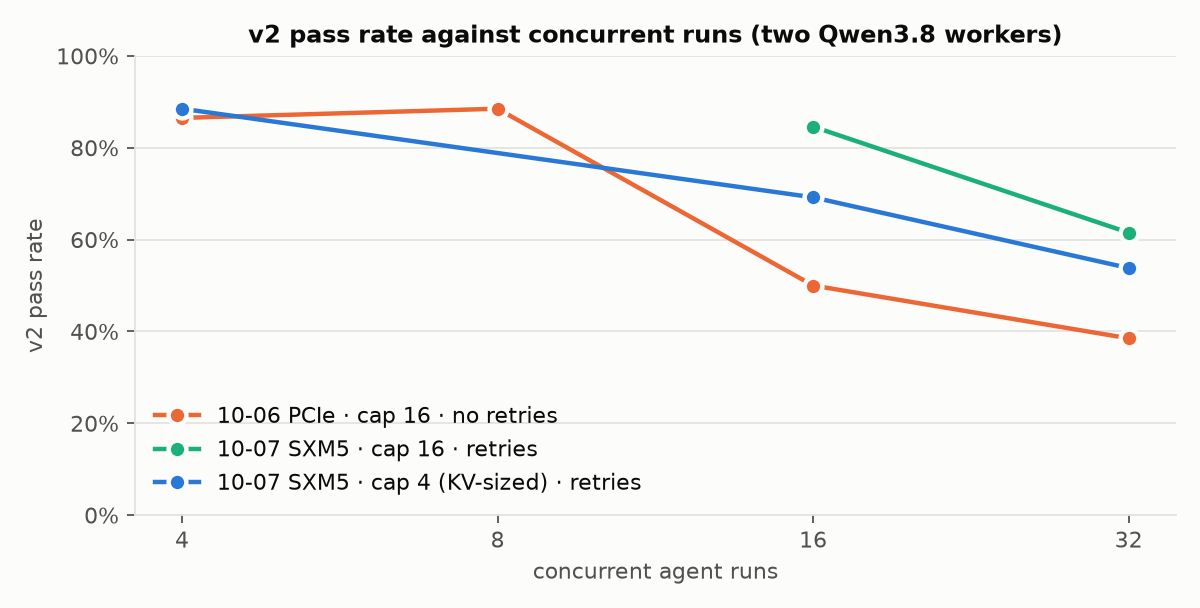

| Run | vLLM preemptions at c=16 | added at c=32 |
|---|---|---|
| 10-06 PCIe · cap 16 · no retries | 0 | 6 |
| 10-07 SXM5 · cap 16 · retries | 9 | 34 |
| 10-07 SXM5 · cap 4 · retries | 1 | 2 |

In [6]:
curves = [
    ("10-06 PCIe · cap 16 · no retries", ORANGE,
     {4: "gw-38-20261006-131640", 8: "sweep-qwen3.8-27b-fp8-c8-20261006-135139",
      16: "sweep-qwen3.8-27b-fp8-c16-20261006-135533", 32: "sweep-qwen3.8-27b-fp8-c32-20261006-135709"}),
    ("10-07 SXM5 · cap 16 · retries", AQUA,
     {16: "sweep-qwen3.8-27b-fp8-c16-20261007-160229", 32: "sweep-qwen3.8-27b-fp8-c32-20261007-160543"}),
    ("10-07 SXM5 · cap 4 (KV-sized) · retries", BLUE,
     {4: "gw-38-kv-20261007-153043", 16: "sweep-qwen3.8-27b-fp8-c16-20261007-151105",
      32: "sweep-qwen3.8-27b-fp8-c32-20261007-151406"}),
]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
levels = [4, 8, 16, 32]                    # evenly spaced: each level doubles the one before
for label, color, runs in curves:
    xs = sorted(runs)
    ys = [summary(runs[c])["pass_rate_v2"] for c in xs]
    ax.plot([levels.index(c) for c in xs], ys, "-o", color=color, linewidth=2, markersize=8,
            markeredgecolor=SURFACE, markeredgewidth=2, label=label)
ax.set(ylim=(0, 1), title="v2 pass rate against concurrent runs (two Qwen3.8 workers)",
       xlabel="concurrent agent runs", ylabel="v2 pass rate")
ax.set_xticks(range(len(levels)), [str(c) for c in levels])
ax.grid(axis="x", visible=False)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="lower left")
show(fig, "knee")
def preempt(stamp, level):
    return sum(total(prom(f"{pod}-sweep-c{level}-{stamp}"), "vllm:num_preemptions_total") for pod in ("vllm-0", "vllm-1"))
rows_t = []
for label, stamp in [("10-06 PCIe · cap 16 · no retries", "20261006-135138"), ("10-07 SXM5 · cap 16 · retries", "20261007-160229"),
                     ("10-07 SXM5 · cap 4 · retries", "20261007-151105")]:
    p16, p32 = preempt(stamp, 16), preempt(stamp, 32)
    rows_t.append([label, f"{p16:.0f}", f"{p32 - p16:.0f}"])
table(["Run", "vLLM preemptions at c=16", "added at c=32"], rows_t)

## 6. What dies where: guard, admit, place, queue

The gateway names every refusal (`orch_shed_total{reason}`). The client sees only 429 (tenant over quota, stays local)
or 503 (capacity, may overflow). Up to 16 concurrent runs the KV shed (`kv_free`) protected vLLM from preemption (F25).
With admission sized to KV the overload moved into the gateway's queue, so refusals became `timeout_queue` (F32).
No restricted request ever left the box.

In [7]:
scrapes = [("10-06 · cap 16 · golden + sweep", "gateway-sweep-c32-20261006-135138"),
           ("10-07 · cap 4 · sweep 16 & 32", "gateway-sweep-c32-20261007-151105"),
           ("10-07 · cap 16 · control 16 & 32", "gateway-kv-control-20261007-160843")]
reasons = sorted({r for _, s in scrapes for r, v in by_label(prom(s), "orch_shed_total", "reason").items() if v})
table(["Gateway counters"] + reasons + ["restricted off-box"],
      [[label] + [f"{by_label(prom(s), 'orch_shed_total', 'reason').get(r, 0):.0f}" for r in reasons]
       + [f"{total(prom(s), 'orch_restricted_offbox_total'):.0f}"] for label, s in scrapes])
display(Markdown("Counters run from each gateway start, and `kubectl set env` restarts the gateway, so each row covers "
                 "only its own runs. The 10-06 `upstream_error` 502s were client aborts, now counted as `client_gone` "
                 "(F28, D-44)."))

| Gateway counters | kv_free | p99_spread | timeout_queue | upstream_error | restricted off-box |
|---|---|---|---|---|---|
| 10-06 · cap 16 · golden + sweep | 28 | 0 | 0 | 5 | 0 |
| 10-07 · cap 4 · sweep 16 & 32 | 4 | 0 | 125 | 0 | 0 |
| 10-07 · cap 16 · control 16 & 32 | 190 | 2 | 0 | 0 | 0 |

Counters run from each gateway start, and `kubectl set env` restarts the gateway, so each row covers only its own runs. The 10-06 `upstream_error` 502s were client aborts, now counted as `client_gone` (F28, D-44).

## 7. Inside the engine: continuous batching and chunked prefill

vLLM rebuilds one batch per worker on every forward pass (an engine step), capped at 32 requests and 8,192 tokens. The
histogram of tokens per step shows both effects: single-token steps are decode with a batch of one, 2–32 tokens are
several requests decoding together, and larger steps carry a prefill. Steps near 8,192 are long prompts that chunked
prefill split. They are rare because the prefix cache keeps each step's uncached tail to a few hundred tokens (F14, F15).

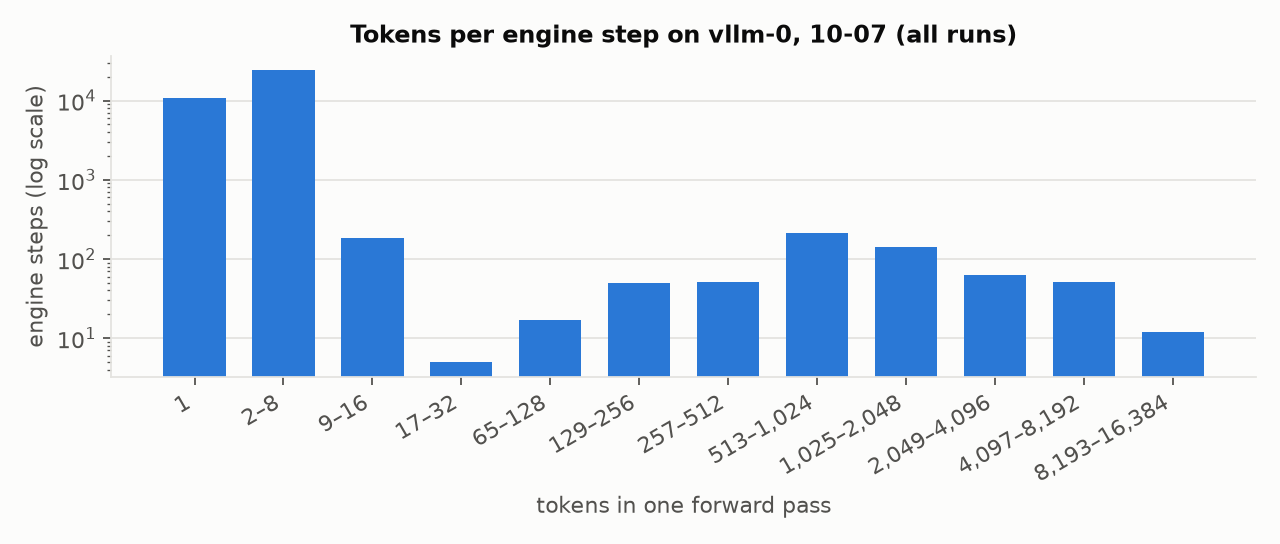

Of **35,626** steps, **63** processed more than 4,096 tokens.

In [8]:
h = histogram(prom("vllm-0-kv-control-20261007-160843"), "vllm:iteration_tokens_total")
labels, counts, lo = [], [], 0
for le, n in h:
    if le == float("inf"):
        labels.append(f">{int(lo):,}")
    else:
        labels.append(f"{int(lo) + 1:,}–{int(le):,}" if le > 1 else "1")
        lo = le
    counts.append(n)
keep = [i for i, n in enumerate(counts) if n]
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(range(len(keep)), [counts[i] for i in keep], color=BLUE, width=0.7)
ax.set_xticks(range(len(keep)), [labels[i] for i in keep], rotation=30, ha="right")
ax.set(yscale="log", title="Tokens per engine step on vllm-0, 10-07 (all runs)", xlabel="tokens in one forward pass",
       ylabel="engine steps (log scale)")
ax.grid(axis="x", visible=False)
show(fig, "engine_steps")
big = sum(n for le, n in h if le > 4096)
display(Markdown(f"Of **{sum(counts):,.0f}** steps, **{big:,.0f}** processed more than 4,096 tokens."))

## 8. Production alerts

`deploy/observability/alerts.yaml` holds five rules. Each threshold comes from the system, and a promtool test checks
that each rule fires on its condition and stays quiet below it (D-45).

In [9]:
text = (ROOT / "deploy" / "observability" / "alerts.yaml").read_text()
names = [(n, " ".join(e.split())) for n, e in
         re.findall(r"- alert: (\w+)\n\s+expr: >?(.*?)\n\s+(?:for|labels):", text, re.S)]
sev = re.findall(r"severity: (\w+)", text)
table(["Alert", "Condition", "Severity"], [[n, f"`{e}`", s] for (n, e), s in zip(names, sev, strict=True)])

| Alert | Condition | Severity |
|---|---|---|
| KVCacheSaturated | `max by (pod) (vllm:kv_cache_usage_perc) > 0.8` | warning |
| GatewayQueueWaitHigh | `histogram_quantile(0.95, sum by (le) (rate(orch_request_duration_seconds_bucket{stage="queue"}[5m]))) > 5` | warning |
| VLLMPreempting | `sum by (pod) (rate(vllm:num_preemptions_total[5m])) > 0` | warning |
| DoctorInconclusiveRateHigh | `sum(increase(doctor_diagnoses_total{status="inconclusive"}[1h])) / sum(increase(doctor_diagnoses_total[1h])) > 0.2` | warning |
| RestrictedRequestOffBox | `increase(orch_restricted_offbox_total[5m]) > 0` | critical |

## 9. Recommendations, and what changes at 10× traffic

- **Model.** Serve Qwen3.8-27B FP8 for diagnosis quality, and keep the 8B as the fallback that fits an A100 slice.
- **Admission.** Keep sizing the in-flight cap from the measured KV pool, but for a small preemption budget rather than
  none (a cap of 6–8 on an H100 half). Lengthen the interactive queue deadline if completion matters more than latency.
- **Placement.** Keep `prefix_then_load`. It cost nothing at low load and saved 10% of prefill at concurrency 4.
- **At 10× traffic:**
  - add workers, not bigger slices. KV per worker is the limiter, so add halves or whole cards and let the gateway
    spread runs. KEDA already scales `statefulset/vllm` on demand per worker and on capacity sheds (D-49, F38);
  - a second gateway replica needs the run table shared or runs partitioned by id (D-42);
  - an overflow backend for non-restricted work (Superlinked serves the same model, F22) turns refusals into slower
    answers;
  - the KV hop starts paying off once contexts grow and moves become common (F35).
- **Settings that do not fit this workload.** The 768-token output cap never bound (F30), and chunked prefill rarely
  binds (F15). The fit calculator needs a hybrid-model correction before it sizes a Qwen3.8 deployment (F5).

## 10. Queue: what runs next

The brief's Part 5 asks who waits where, and what runs next when the load mixes. `make bench` ends with a probe session
(D-48). A golden run at concurrency 4 is the background load. On a schedule, three ~14k-token batch prompts arrive,
three clients leave mid-answer, and one worker is deleted and left to return. `make export` then pulls the node's
Prometheus history for the bench window into `metrics/ts-*.json`, together with the probe times. The charts mark those
times with vertical lines, and their time axis counts minutes from the start of the window.

In [10]:
import json

from report.results import series, timeseries

ts = timeseries()
NO_TS = "No time series yet: run `make bench` on the GPU (it ends with `make export`)"
SLOTS = [BLUE, ORANGE, AQUA, "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]   # the categorical order, fixed
MARKS = {"big_prompt_sent": ("--", "14k-token prompt sent"), "client_gone_aborted": (":", "client left"),
         "worker_deleted": ("-.", "worker deleted"), "worker_phase": ((0, (6, 2, 1, 2, 1, 2)), "worker phase change")}
PHASES = ["down", "warming", "ready"]
PODS = sorted({lab["pod"] for q in (ts or {}).get("series", {}).values() for r in q["results"]
               for lab in [r["labels"]] if "pod" in lab})

def color(pod):
    return SLOTS[PODS.index(pod) % len(SLOTS)] if pod in PODS else INK2

def lines(name, key="pod", scale=1.0, only=None):
    """One line per label value of an exported query, in minutes; empty without an export or when the query failed."""
    out = []
    for labels, t, v in (series(ts, name) if ts else []):
        k = labels.get(key, "all")
        if only is None or k == only:
            out.append((k, color(k), [x / 60 for x in t], [y * scale for y in v]))
    return sorted(out, key=lambda line: line[0])

def phase_lines():
    at = {}
    for labels, t, v in (series(ts, "gw_phase") if ts else []):
        for x, y in zip(t, v, strict=True):
            if y == 1 and labels.get("phase") in PHASES:
                at.setdefault(labels.get("pod", "all"), {})[x / 60] = PHASES.index(labels["phase"])
    return [(pod, color(pod), sorted(at[pod]), [at[pod][x] for x in sorted(at[pod])]) for pod in sorted(at)]

def plot(name, title, panels, marks=(), sharey=False):
    """Small multiples on one time axis. A panel is (title, y label, lines[, y tick labels])."""
    if ts is None:
        print(NO_TS)
        return
    ev = [(e["kind"], (e["t"] - ts["start"]) / 60) for e in ts["events"] if e["kind"] in marks]
    fig, axes = plt.subplots(len(panels), 1, figsize=(8.5, 1.0 + 1.9 * len(panels)), sharex=True, sharey=sharey,
                             squeeze=False)
    legends = set()
    for ax, (head, ylabel, drawn, *ticks) in zip(axes[:, 0], panels, strict=True):
        for label, c, t, v in drawn:
            ax.plot(t, v, color=c, linewidth=2, label=label)
        if not drawn:
            ax.text(0.5, 0.5, "no data in this export", transform=ax.transAxes, ha="center", va="center", color=INK2)
        seen = set()
        for kind, t in ev:
            style, text = MARKS[kind]
            ax.axvline(t, color=INK2, linestyle=style, linewidth=1, label=None if kind in seen else text)
            seen.add(kind)
        if ticks:
            ax.set_yticks(range(len(ticks[0])), ticks[0])
            ax.set_ylim(-0.3, len(ticks[0]) - 0.7)
        else:
            ax.set_ylim(bottom=0)
        ax.set_title(head, loc="left", fontsize=9.5)
        ax.set_ylabel(ylabel)
        ax.grid(axis="x", visible=False)
        names = tuple(ax.get_legend_handles_labels()[1])
        if names and names not in legends:                     # a panel repeating the legend above it gets none
            legends.add(names)
            ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8.5)
    span = (ts["end"] - ts["start"]) / 60
    times = [t for _, t in ev]
    axes[-1, 0].set_xlim((max(0, min(times) - 1.5), min(span, max(times) + 4)) if times else (0, span))
    axes[-1, 0].set_xlabel("minutes since the window started")
    fig.suptitle(title, fontweight="bold", fontsize=11)
    show(fig, f"queue_{name}")

if ts is None:
    print(NO_TS)
else:
    failed = ", ".join(f"`{n}` ({why})" for n, why in sorted(ts["errors"].items())) or "none"
    display(Markdown(f"Export `{ts['tag']}`: {(ts['end'] - ts['start']) / 60:.0f} minutes at a {ts['step_s']} s step, "
                     f"{len(ts['series'])} queries, {len(ts['events'])} probe events. Failed queries: {failed}."))

No time series yet: run `make bench` on the GPU (it ends with `make export`)


### Who waits in our queue, and who waits in vLLM's

The gateway holds a request in its own queue until the worker has room under the in-flight cap, 4 per H100 half
(D-43). Once placed, the request belongs to vLLM. It waits in vLLM's queue (`num_requests_waiting`) until the scheduler
has KV blocks and a batch slot for it, then runs (`num_requests_running`). vLLM puts a preempted request back in its
waiting queue, so preemption shows as waiting above 0 while running drops. With the cap sized to KV, the overload
should sit in the gateway's queue, and vLLM's waiting count should stay near 0 (F32). Each worker gets two panels on
one shared scale, the gateway's view on top and vLLM's below.

The same panels answer the per-worker question. The blue line in each gateway panel is `orch_replica_queue_depth` for
that worker under the mixed load. The second chart is the gateway's shed rate by reason. It shows whether the queue
overflowed (`queue_full`), waited past its deadline (`timeout_queue`), or the door refused for KV (`kv_free`).

In [11]:
panels = []
for pod in PODS:
    q, f = lines("gw_queue_depth", only=pod), lines("gw_inflight", only=pod)
    w, r = lines("vllm_waiting", only=pod), lines("vllm_running", only=pod)
    panels.append((f"{pod} · gateway", "requests", [("queued", BLUE, *x[2:]) for x in q]
                   + [("in flight", ORANGE, *x[2:]) for x in f]))
    panels.append((f"{pod} · vLLM", "requests", [("waiting", BLUE, *x[2:]) for x in w]
                   + [("running", ORANGE, *x[2:]) for x in r]))
plot("waiting", "Requests waiting and in service, gateway against vLLM, per worker", panels or [("no workers", "", [])],
     marks=("big_prompt_sent", "client_gone_aborted", "worker_deleted"), sharey=True)
if ts is not None:
    sheds = [(reason, SLOTS[i % len(SLOTS)], t, v)                    # colored by place among all reasons, not those that fired
             for i, (reason, _, t, v) in enumerate(lines("gw_shed_rate", key="reason")) if any(v)]
    if sheds:
        plot("shed", "Gateway refusals by reason", [("all workers", "refusals per second", sheds)],
             marks=("big_prompt_sent", "client_gone_aborted", "worker_deleted"))
    else:
        display(Markdown("The gateway refused nothing in this window."))

No time series yet: run `make bench` on the GPU (it ends with `make export`)


### A 32k-token RAG prompt next to a short agent step

A 32k prompt can't run here. `max_model_len` is 24,576 on an H100 half, so vLLM rejects it with a 400 after the
gateway forwards it. The probe sends ~14k tokens instead, which takes two 8,192-token prefill chunks and still passes
the door while golden runs share the pool. Our queue serves interactive work before batch. At a full queue, an
interactive arrival displaces the newest batch waiter, which gets `queue_full`. At the door the gateway reserves the request's estimated
tokens against the worker's free KV, so a long prompt that would fill the pool is refused with `kv_free` rather than
admitted. Inside vLLM the scheduler serves running requests first on every engine step, and chunked prefill splits
the long prompt into 8,192-token pieces. The agent's decode slows while those pieces run, but it does not stop. The
chart shows inter-token latency and tokens per engine step around each long prompt.

In [12]:
plot("long_prompt", "Decode speed and step size around the 14k-token prompts",
     [("inter-token latency, p95", "ms", lines("vllm_itl_p95", scale=1000)),
      ("tokens per engine step, p95", "tokens", lines("vllm_iter_tokens_p95"))],
     marks=("big_prompt_sent",))

No time series yet: run `make bench` on the GPU (it ends with `make export`)


### PagedAttention and the prefix cache

Both manage the same KV blocks, and they solve different problems. PagedAttention stores each request's KV in
fixed-size blocks, so a request wastes less than one block, but each request still gets blocks of its own. The prefix
cache hashes full blocks of the prompt, and a later request with the same prefix points at the blocks already there.
The numbers below come from the committed golden rows and vLLM's own pool report.

In [13]:
r = rows("gw-38-20261006-131640")
shared = median([x["cached_tokens"][0] for x in r if x["cached_tokens"] and x["cached_tokens"][0]])
pool, runs = kv_measured("qwen3.8-27b-fp8", "h100-half"), 16
display(Markdown(
    f"A run's first call finds **{shared:,}** tokens already cached. That is the shared prefix, counted in whole blocks. "
    f"At {runs} concurrent runs, one copy per run would take **{runs * shared:,}** tokens, {runs * shared / pool:.0%} "
    f"of an H100 half's measured pool ({pool:,} tokens), before any run's own history. The prefix cache keeps one copy "
    f"per worker, {shared / pool:.1%} of the pool. PagedAttention alone would have removed fragmentation and still "
    f"stored all {runs} copies (F8–F11)."))

A run's first call finds **3,920** tokens already cached. That is the shared prefix, counted in whole blocks. At 16 concurrent runs, one copy per run would take **62,720** tokens, 123% of an H100 half's measured pool (51,092 tokens), before any run's own history. The prefix cache keeps one copy per worker, 7.7% of the pool. PagedAttention alone would have removed fragmentation and still stored all 16 copies (F8–F11).

### Engine flags for this workload

Every model shares these engine settings (INV-15), read here from `deploy/serving.json`.

In [14]:
engine = json.loads((ROOT / "deploy" / "serving.json").read_text())["engine"]
display(Markdown(
    f"`--max-num-seqs {engine['max_num_seqs']}` sits above the gateway's in-flight cap, so the overload waits in the "
    f"gateway's queue, which knows priority and tenant, and vLLM's own waiting queue stays short. "
    f"`--max-num-batched-tokens {engine['max_num_batched_tokens']:,}` bounds the activation peak that `serving/fit.py` "
    f"charges against GPU memory, and it is the chunk size for long prefills. It rarely binds on this workload, because "
    f"the prefix cache keeps each step's new tail short (F15)."))

`--max-num-seqs 32` sits above the gateway's in-flight cap, so the overload waits in the gateway's queue, which knows priority and tenant, and vLLM's own waiting queue stays short. `--max-num-batched-tokens 8,192` bounds the activation peak that `serving/fit.py` charges against GPU memory, and it is the chunk size for long prefills. It rarely binds on this workload, because the prefix cache keeps each step's new tail short (F15).

### When KV fills after admission

The gateway checks free KV at the door and sheds with `kv_free` below its line (section 6). Admitted requests keep
growing their history after that, and when the pool fills, vLLM preempts a running request and recomputes it later
(sections 5 and 6, F25, F33). Sizing the cap to the pool cut preemptions by ~95% and moved the overload into the
gateway's queue (F36). The chart shows KV use and preemptions per worker across the probe session.

In [15]:
plot("kv_full", "KV use and vLLM preemptions per worker",
     [("KV cache in use", "% of pool", lines("vllm_kv_usage", scale=100)),
      ("preemptions", "per second", lines("vllm_preempt_rate"))],
     marks=("big_prompt_sent", "client_gone_aborted", "worker_deleted"))

No time series yet: run `make bench` on the GPU (it ends with `make export`)


### A client that leaves mid-answer

When the client disconnects, Go cancels the gateway's request context, and that cancels the upstream call to vLLM.
vLLM should then see the closed connection, abort the request and free its KV blocks. The probe checks that. The
gateway records the request as `client_gone`, not as a worker error (D-44). The chart shows vLLM's aborted-request
count and KV use around each client that left.

In [16]:
plot("client_gone", "Aborted requests and KV use around the clients that left",
     [("requests aborted (cumulative)", "requests", lines("vllm_aborts")),
      ("KV cache in use", "% of pool", lines("vllm_kv_usage", scale=100))],
     marks=("client_gone_aborted",))

No time series yet: run `make bench` on the GPU (it ends with `make export`)


### After a worker returns

There is no ramp. A returning worker serves only after two warm-up probes answer quickly. Then it gets full traffic,
bounded by the in-flight cap and spread by load-aware placement (D-48). The chart shows the gateway's p99 latency,
placements per worker and each worker's phase around the deleted worker's return.

In [17]:
plot("worker_return", "Latency, placement and phase around the deleted worker's return",
     [("end-to-end latency, p99, all workers", "seconds", [("p99", BLUE, *x[2:]) for x in lines("gw_e2e_p99")]),
      ("placements", "per second", lines("gw_pick_rate")),
      ("phase", "", phase_lines(), PHASES)],
     marks=("worker_deleted", "worker_phase"))

No time series yet: run `make bench` on the GPU (it ends with `make export`)
